In [23]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json

pd.set_option('display.max_columns', None)

In [24]:
OPTIONS = json.loads(open('info.json', 'r', encoding='utf-8').read())
OPTIONS

{'variable': 'wz', 'test': 1, 'limits': [15, 999]}

In [25]:
TARGET_VAR = OPTIONS.get('variable')
TEST_VAR   = OPTIONS.get('test')
VIEW_LIMITS = (0.3, 0.6)

In [26]:
MEASURE_VAR   = 'measure_'   + TARGET_VAR
KONGSBERG_VAR = 'kongsberg_' + TARGET_VAR

# IMPORTANDO DADOS

In [27]:
df_measure = pd.read_csv('Measure/DataBase.csv')
df_measure

,measure_pitch,measure_ay,measure_az,measure_q1,measure_yaw,measure_wy,time,measure_roll,measure_wz,measure_q3,measure_wx,measure_q0,measure_q2,measure_ax,measure_e
0,-2041,995881,10237,0,414,-42019,0.000000,542,16331,0,44195,0,0,-34458,0.0
1,-2041,998837,15545,0,412,-27233,0.010000,543,-24311,0,17916,0,0,-41115,0.0
2,-2042,996077,12297,0,411,-20237,0.020000,544,13074,0,-56503,0,0,-36813,0.0
3,-2043,996806,8643,0,410,-39449,0.030001,544,-33316,0,22885,0,0,-35112,0.0
4,-2043,996630,8171,0,409,16468,0.040001,544,30717,0,8082,0,0,-35739,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12490,2912,995215,12186,0,1069,68631,136.541000,77,-16302,0,9921,0,0,49244,0.0
12491,2914,999522,12073,0,1075,30352,136.550995,78,-27489,0,-17027,0,0,51033,0.0
12492,2915,995420,12427,0,1081,53393,136.561005,80,-9455,0,617,0,0,47824,0.0
12493,2915,999482,9165,0,1087,42491,136.570999,82,-24669,0,-28122,0,0,43473,0.0


In [28]:
df_kongsberg = pd.read_csv('Kongsberg/DataBase.csv')
df_kongsberg

,kongsberg_q0,kongsberg_ay,kongsberg_q1,kongsberg_q3,kongsberg_q2,kongsberg_wy,kongsberg_pitch,kongsberg_roll,kongsberg_yaw,kongsberg_wz,kongsberg_wx,kongsberg_ax,time,kongsberg_sample_time,kongsberg_la_pos_mon_d,kongsberg_az
0,0.7016,-9.775,0.7124,0.01238,-0.01197,-0.225745,-1.973267,90.871106,0.018358,-0.190508,-0.437281,-0.3497,0.000000,105000000.0,-0.02016,0.15330
1,0.7018,-9.777,0.7122,0.01226,-0.01197,-0.195149,-1.963526,90.871106,0.008743,-0.012857,-0.209932,-0.3400,0.098466,205000000.0,-0.02187,0.12410
2,0.7018,-9.779,0.7122,0.01222,-0.01221,-0.173492,-1.979569,90.813811,-0.013327,0.228324,0.027118,-0.3360,0.191033,305000000.0,-0.02364,0.10510
3,0.7019,-9.783,0.7121,0.01232,-0.01241,0.016163,-2.003633,90.813811,-0.020976,0.200593,-0.097976,-0.3610,0.295896,405000000.0,-0.02549,0.10260
4,0.7019,-9.787,0.7121,0.01217,-0.01241,-0.153610,-1.991028,90.813811,-0.033650,-0.236460,0.117514,-0.3827,0.389251,505000000.0,-0.02747,0.10320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1347,0.6862,-9.772,0.6997,-0.19410,-0.04343,-0.099752,12.238379,88.980346,-19.555050,0.099809,0.147078,0.5107,134.696582,805000000.0,10.00000,-0.08408
1348,0.6862,-9.780,0.6997,-0.19400,-0.04362,-0.101127,12.221190,88.980346,-19.566509,0.298339,0.142896,0.4834,134.791253,905000000.0,10.00000,-0.07341
1349,0.6860,-9.777,0.6998,-0.19410,-0.04386,-0.338160,12.209731,89.037641,-19.589427,0.035753,0.159855,0.4994,134.904581,5000000.0,10.00000,-0.07292
1350,0.6859,-9.777,0.6999,-0.19430,-0.04415,-0.375058,12.204001,89.037641,-19.629534,-0.030808,0.215432,0.4787,134.999204,105000000.0,10.00000,-0.07352


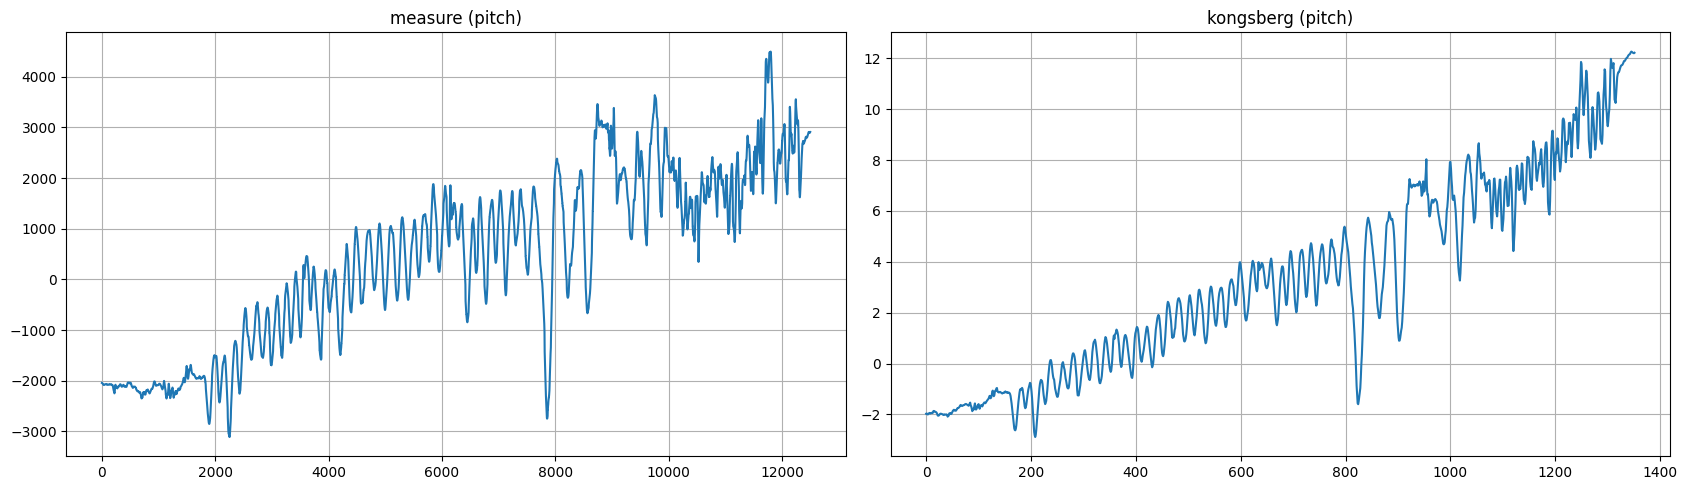

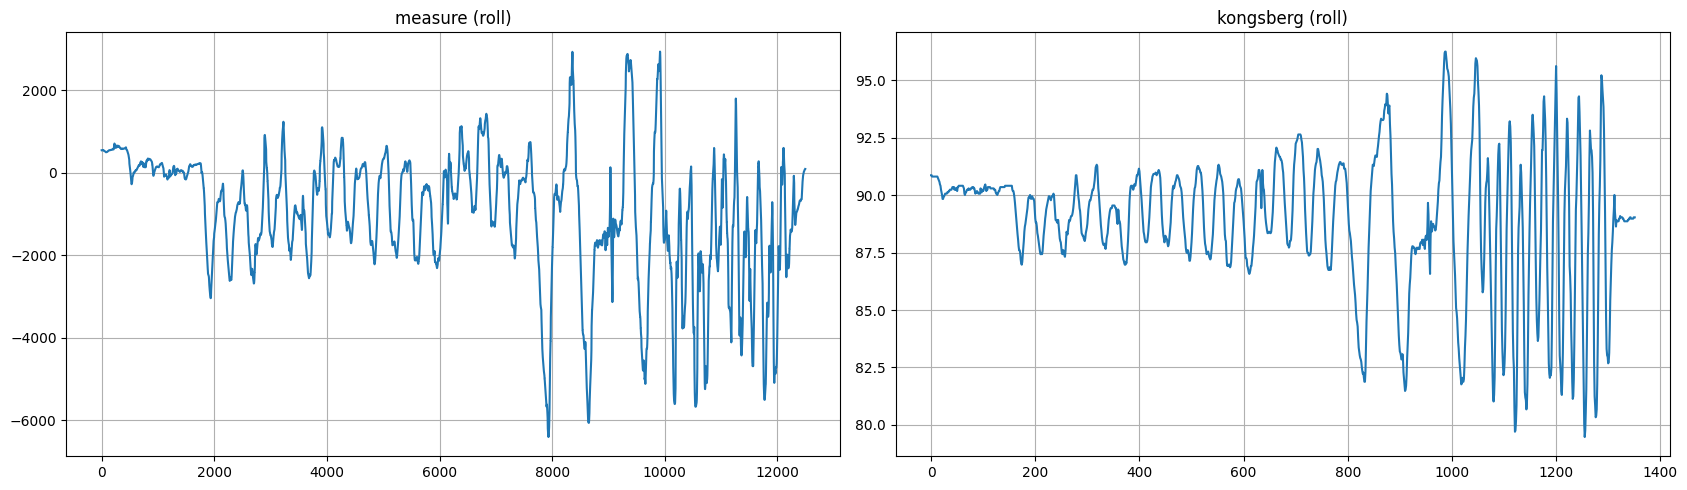

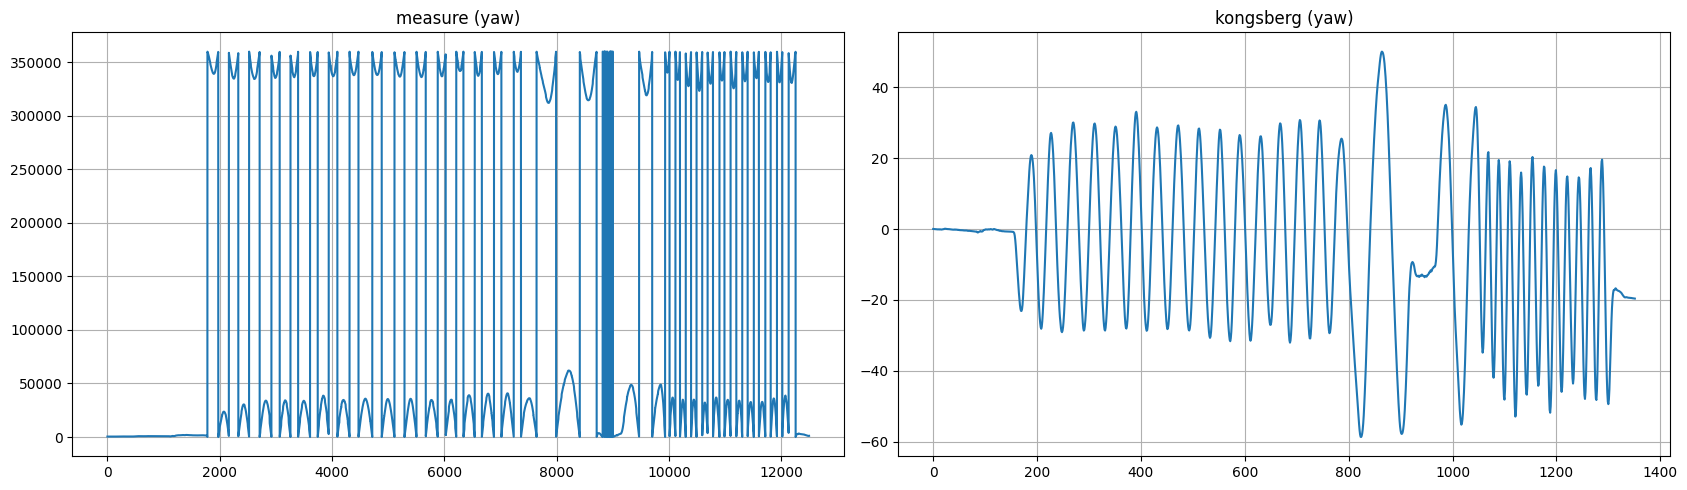

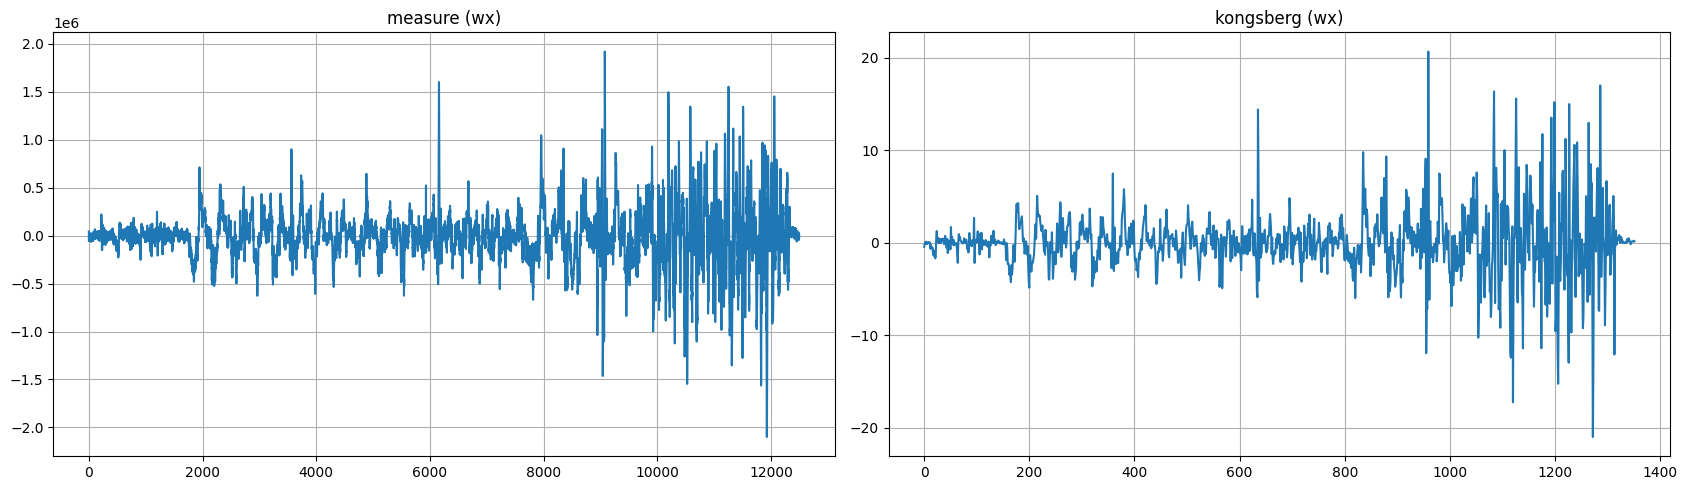

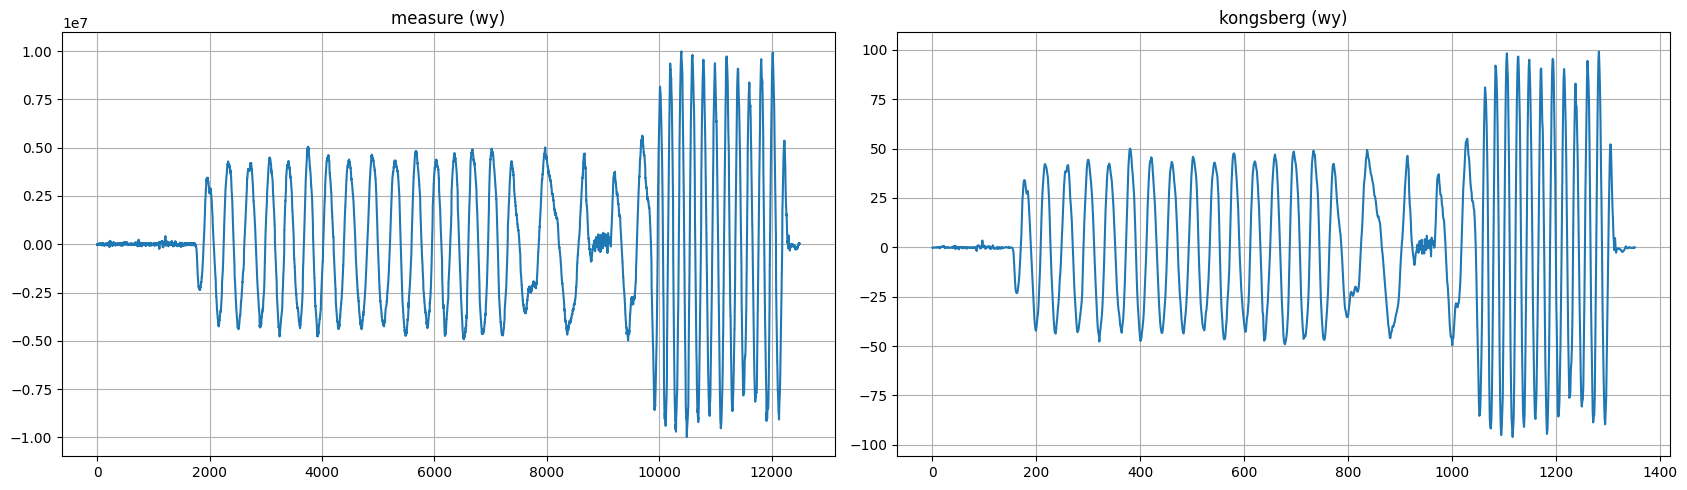

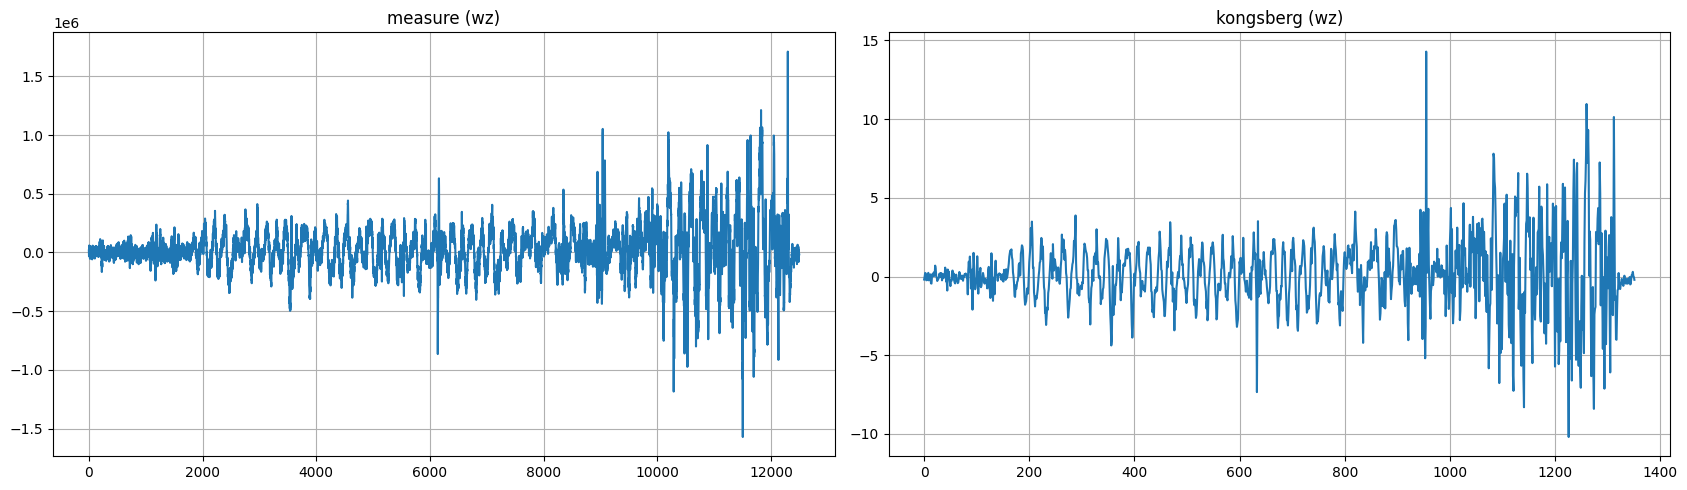

In [29]:
def compareAxis(data, figsize=None):
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=figsize if figsize is not None else (6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        plt.subplot(numRows, numCols, i+1)
        plt.plot(values)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()


for var in ['pitch', 'roll', 'yaw', 'wx', 'wy', 'wz']:
    compareAxis({
        f'measure ({var})':   df_measure[f'measure_{var}'], 
        f'kongsberg ({var})': df_kongsberg[f'kongsberg_{var}']
    }, figsize=(17, 5))

In [30]:
first_df  = df_kongsberg.copy() if len(df_kongsberg) <= len(df_measure) else df_measure
second_df = df_kongsberg.copy() if len(df_kongsberg) >= len(df_measure) else df_measure

df = pd.merge_asof(first_df, second_df, on='time', direction='nearest')
df

,kongsberg_q0,kongsberg_ay,kongsberg_q1,kongsberg_q3,kongsberg_q2,kongsberg_wy,kongsberg_pitch,kongsberg_roll,kongsberg_yaw,kongsberg_wz,kongsberg_wx,kongsberg_ax,time,kongsberg_sample_time,kongsberg_la_pos_mon_d,kongsberg_az,measure_pitch,measure_ay,measure_az,measure_q1,measure_yaw,measure_wy,measure_roll,measure_wz,measure_q3,measure_wx,measure_q0,measure_q2,measure_ax,measure_e
0,0.7016,-9.775,0.7124,0.01238,-0.01197,-0.225745,-1.973267,90.871106,0.018358,-0.190508,-0.437281,-0.3497,0.000000,105000000.0,-0.02016,0.15330,-2041,995881,10237,0,414,-42019,542,16331,0,44195,0,0,-34458,0.0
1,0.7018,-9.777,0.7122,0.01226,-0.01197,-0.195149,-1.963526,90.871106,0.008743,-0.012857,-0.209932,-0.3400,0.098466,205000000.0,-0.02187,0.12410,-2049,996410,9993,0,404,16833,542,6044,0,-8122,0,0,-35491,0.0
2,0.7018,-9.779,0.7122,0.01222,-0.01221,-0.173492,-1.979569,90.813811,-0.013327,0.228324,0.027118,-0.3360,0.191033,305000000.0,-0.02364,0.10510,-2069,997799,11574,0,405,23077,547,-16278,0,-8988,0,0,-37327,0.0
3,0.7019,-9.783,0.7121,0.01232,-0.01241,0.016163,-2.003633,90.813811,-0.020976,0.200593,-0.097976,-0.3610,0.295896,405000000.0,-0.02549,0.10260,-2080,996266,9130,0,411,9916,544,24291,0,-22547,0,0,-38009,0.0
4,0.7019,-9.787,0.7121,0.01217,-0.01241,-0.153610,-1.991028,90.813811,-0.033650,-0.236460,0.117514,-0.3827,0.389251,505000000.0,-0.02747,0.10320,-2081,994063,8906,0,414,-22535,533,-2136,0,-22888,0,0,-37566,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1347,0.6862,-9.772,0.6997,-0.19410,-0.04343,-0.099752,12.238379,88.980346,-19.555050,0.099809,0.147078,0.5107,134.696582,805000000.0,10.00000,-0.08408,1766,949448,7663,0,3067,-324366,-1214,-136565,0,152352,0,0,-4162,0.0
1348,0.6862,-9.780,0.6997,-0.19400,-0.04362,-0.101127,12.221190,88.980346,-19.566509,0.298339,0.142896,0.4834,134.791253,905000000.0,10.00000,-0.07341,2001,1035621,960,0,2881,-169033,-1032,-405625,0,222068,0,0,34201,0.0
1349,0.6860,-9.777,0.6998,-0.19410,-0.04386,-0.338160,12.209731,89.037641,-19.589427,0.035753,0.159855,0.4994,134.904581,5000000.0,10.00000,-0.07292,2368,1002344,-1721,0,2761,-82392,-957,-204711,0,34917,0,0,50603,0.0
1350,0.6859,-9.777,0.6999,-0.19430,-0.04415,-0.375058,12.204001,89.037641,-19.629534,-0.030808,0.215432,0.4787,134.999204,105000000.0,10.00000,-0.07352,2554,995492,3564,0,2718,-8750,-926,-126821,0,3074,0,0,46687,0.0


In [31]:
df.to_csv('../../Calibration/files/DataBase.csv', index=None)